<a href="https://colab.research.google.com/github/AzizulHakim00/Glaucomma/blob/main/Glaucomma_RimGraphDG_Single_Cell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RimGraph-DG Live Run
**Device:** `Tesla T4`  
**Run:** `paper_run_v3`  
**Fold:** held-out `REFUGE`  
**Epoch:** `5/25`  
Best source-validation score: **0.4845** at epoch **4**

epoch,train_loss,val_loss,val_auroc,val_auprc,val_f1,val_dice_disc,val_dice_cup
1,0.1323,0.1169,0.4941,0.2882,0.3711,0.0000,0.0000
2,0.1268,0.1161,0.5966,0.3416,0.4065,0.0000,0.0000
3,0.1221,0.1135,0.5784,0.3491,0.2319,0.0000,0.0000
4,0.1196,0.1138,0.6817,0.4382,0.4481,0.0000,0.0000
5,0.1164,0.1186,0.5949,0.3354,0.4691,0.0000,0.0000


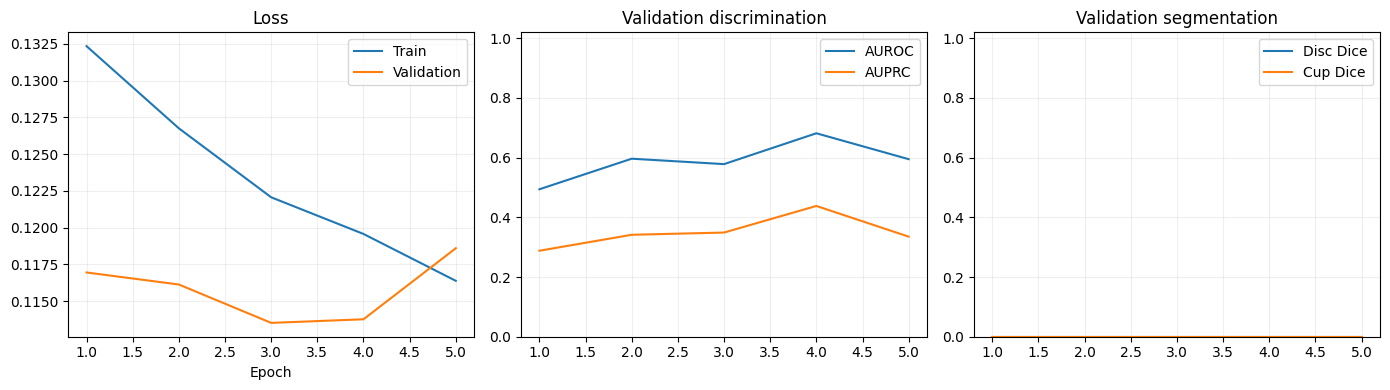

### Completed external folds

auroc,auprc,accuracy,balanced_accuracy,sensitivity,specificity,f1,mcc,brier,ece,held_out_source
0.7884,0.5612,0.4169,0.5952,0.9643,0.2261,0.4609,0.2185,0.2412,0.2716,ORIGA


In [ ]:
# RimGraph-DG v3 — select a T4 GPU runtime and run this ONE cell.
# Results and checkpoints are mirrored to Google Drive and resume safely after interruption.
GLAUCOMMA_OVERRIDES = {
    'manual_data_dir': '',
    'fast_dev_run': False,
    'run_optuna': False,
    'optuna_trials': 8,
    'epochs': 25,
    'image_size': 320,
    'batch_size': 2,
    'grad_accum': 2,
    'num_workers': 0,
    'run_name': 'paper_run_v3',
    'code_revision': 'rimgrah-dg-runtime-v3-20260802',
}

import urllib.request
COMMIT = 'a2621ca580f1974b13ebb904f420f97f5461f50b'
ROOT = f'https://raw.githubusercontent.com/AzizulHakim00/Glaucomma/{COMMIT}'
parts = [f'runner_parts/part_{i:02d}.py' for i in range(8)]
code = '\n'.join(urllib.request.urlopen(f'{ROOT}/{name}').read().decode('utf-8') for name in parts)
patch_v2_source = urllib.request.urlopen(f'{ROOT}/runner_patch_v2.py').read().decode('utf-8')
patch_v3_source = urllib.request.urlopen(f'{ROOT}/runner_patch_v3.py').read().decode('utf-8')
patch_v2_ns, patch_v3_ns = {}, {}
exec(compile(patch_v2_source, 'runner_patch_v2.py', 'exec'), patch_v2_ns, patch_v2_ns)
exec(compile(patch_v3_source, 'runner_patch_v3.py', 'exec'), patch_v3_ns, patch_v3_ns)
code = patch_v2_ns['apply_patches'](code)
code = patch_v3_ns['apply_patches_v3'](code)
compile(code, 'rimgraph_dg_single_cell_v3.py', 'exec')
exec(code, globals(), globals())
